# Collab code

In [ ]:
# Create the kaggle.json file with your credentials
!mkdir -p ~/.kaggle

# Replace 'your_username' with your actual Kaggle username
# Your API key is: KGAT_ff9d24c578d21a4340ae7b06f06cd5d8
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('''{
  "username": "amrbadawi",
  "key": "KGAT_ff9d24c578d21a4340ae7b06f06cd5d8"
}''')

# Set proper permissions
!chmod 600 ~/.kaggle/kaggle.json

# Or your specific dataset (replace with actual name)
!kaggle datasets download -d 'briscdataset/brisc2025'

!unzip -q 'brisc2025.zip'  # Replace with actual filename
!ls -la  # List files to confirm

# import & Check GPU

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")

CUDA available: True
GPU name: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Current device: 0


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
from ultralytics import YOLO
import torch

# Preprocessing

In [ ]:
def preprocess_image(img):
    # Resize to 224x224
    img = cv2.resize(img, (256, 256))
    
    # Convert to float32
    img = img.astype(np.float32)
    
    return img

# Load Data

In [4]:
import os
import cv2
import numpy as np

def load_images_from_folder(folder, color_mode='grayscale', normalize=True):
    images = []
    labels = []
    
    # Get class names from subfolder names (alphabetical order for consistency)
    class_names = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])
    class_to_idx = {name: i for i, name in enumerate(class_names)}
    
    # Determine number of channels
    if color_mode == 'grayscale':
        read_flag = cv2.IMREAD_GRAYSCALE
        channels = 1
    else:  # rgb
        read_flag = cv2.IMREAD_COLOR
        channels = 3
    
    for class_name in class_names:
        class_folder = os.path.join(folder, class_name)
        if not os.path.exists(class_folder):
            print(f"Warning: Folder does not exist: {class_folder}")
            continue
        
        file_count = 0
        for filename in os.listdir(class_folder):
            img_path = os.path.join(class_folder, filename)
            # Check if it's a file and has a valid image extension
            if not os.path.isfile(img_path):
                continue
            if not img_path.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):
                continue
            
            try:
                img = cv2.imread(img_path, read_flag)
                if img is None:
                    print(f"Failed to load: {img_path}")
                    continue
                
                img = preprocess_image(img)
                images.append(img)
                labels.append(class_to_idx[class_name])
                file_count += 1
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
        
        print(f"Loaded {file_count} images from class '{class_name}'")
    
    if len(images) == 0:
        raise ValueError(f"No images found in folder: {folder}")
    
    # Convert to numpy arrays
    images = np.array(images)
    labels = np.array(labels)
    
    # Normalize if requested
    if normalize:
        images /= 255.0
    
    print(f"Total images loaded: {len(images)}")
    return images, labels, class_names

In [ ]:
folder_train ='../../Dataset/brisc2025/classification_task/train'
folder_test  ='../../Dataset/brisc2025/classification_task/test'

images_train,labels_train,class_names=load_images_from_folder(folder_train)
images_test,labels_test,class_names=load_images_from_folder(folder_test)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Amr badawi\AppData\Local\Temp\ipykernel_7376\3673409293.py:1: SyntaxWarning: invalid escape sequence '\.'
  folder_train ='..\..\Dataset/brisc2025/classification_task/train'
C:\Users\Amr badawi\AppData\Local\Temp\ipykernel_7376\3673409293.py:2: SyntaxWarning: invalid escape sequence '\.'
  folder_test  ='..\..\Dataset/brisc2025/classification_task/test'


Loaded 1147 images from class 'glioma'
Loaded 1329 images from class 'meningioma'
Loaded 1067 images from class 'no_tumor'
Loaded 1457 images from class 'pituitary'
Total images loaded: 5000
Loaded 254 images from class 'glioma'
Loaded 306 images from class 'meningioma'
Loaded 140 images from class 'no_tumor'
Loaded 300 images from class 'pituitary'
Total images loaded: 1000


# Test Data

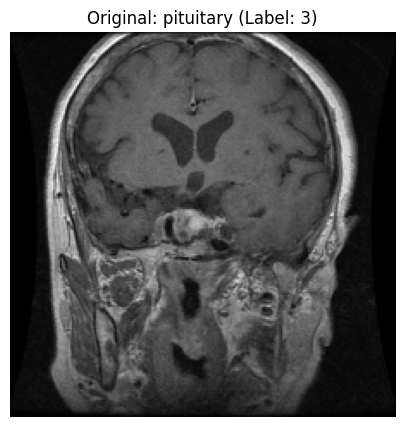

In [6]:
# Only proceed if we have images
if len(images_train) > 0:
    images_train = np.array(images_train, dtype=np.float32)
    labels_train = np.array(labels_train)

    # Step 3: Visualize a sample and its augmentation
    sample_index = np.random.randint(len(images_train))
    sample_image = images_train[sample_index]
    sample_label = labels_train[sample_index]

    plt.figure(figsize=(10, 5))
    plt.imshow(sample_image, cmap='gray')
    plt.title(f'Original: {class_names[sample_label]} (Label: {sample_label})')
    plt.axis('off')
    plt.show()

Save preprocessing To a folder

In [7]:
import os
import cv2
import numpy as np

def save_preprocessed_dataset(images, labels, class_names, root_dir):
    os.makedirs(root_dir, exist_ok=True)
    for class_name in class_names:
        class_dir = os.path.join(root_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

    for i, (img, label) in enumerate(zip(images, labels)):
        # img is float32 in [0,1] -> convert back to uint8 [0,255]
        img_uint8 = (img * 255).astype(np.uint8)

        # If your image is grayscale (shape H,W), add channel dimension
        if img_uint8.ndim == 2:
            img_uint8 = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR)   # YOLO expects 3 channels

        # Determine class name
        class_name = class_names[label]
        filename = f"{i:06d}.jpg"
        filepath = os.path.join(root_dir, class_name, filename)
        cv2.imwrite(filepath, img_uint8)

# Define output folders
train_out = "preprocessed_train2"
test_out  = "preprocessed_test2"

# Save both datasets
save_preprocessed_dataset(images_train, labels_train, class_names, train_out)
save_preprocessed_dataset(images_test,  labels_test,  class_names, test_out)

print(f"Training images saved to {train_out}/")
print(f"Test images saved to {test_out}/")

Training images saved to preprocessed_train2/
Test images saved to preprocessed_test2/


In [ ]:
import shutil

# Source folders
train_src = "preprocessed_train2"
test_src  = "preprocessed_test2"

# Destination parent
parent = "yolo_cls_dataset2"
os.makedirs(parent, exist_ok=True)

# Move train → parent/train (overwrite if exists)
train_dest = os.path.join(parent, "train")
if os.path.exists(train_dest):
    shutil.rmtree(train_dest)
shutil.move(train_src, train_dest)

# Move test → parent/val (overwrite if exists)
val_dest = os.path.join(parent, "val")
if os.path.exists(val_dest):
    shutil.rmtree(val_dest)
shutil.move(test_src, val_dest)

'preprocessed_data2\\val'

# Train the model

In [ ]:
# Load a pre-trained YOLOv8 classification model (nano version)
model = YOLO('yolov8n-cls.pt')   # you can also use 'yolov8s-cls.pt'

If you want to (and overwrite the old run with same name ), you can set exist_ok=True in the training arguments:


Or resume=True if you want to resume on the old one

In [ ]:
model.train(
    data='yolo_cls_dataset2',          
    epochs=30,
    imgsz=224,
    batch=16,
    name='yolo_with_my_preproc2', # named yolo_with_my_preproc3 privously
    exist_ok=True,
    # resume=True,
    device=0,
    workers=4,
    #for augmentation
    degrees=10.0,          # allow random rotation up to ±10°
    fliplr=0.5,             # keep horizontal flips
    hsv_h=0.02             # slightly more hue variation
)

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.14  Python-3.12.2 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=preprocessed_data2, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001EA45D0FCE0>
curves: []
curves_results: []
fitness: 0.99549999833107
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9909999966621399, 'metrics/accuracy_top5': 1.0, 'fitness': 0.99549999833107}
save_dir: WindowsPath('E:/Amr college/Grad project/Models/YOLO_classify/runs/classify/yolo_with_my_preproc3')
speed: {'preprocess': 0.1325707999998258, 'inference': 0.3398288999998158, 'loss': 0.0002955999998448533, 'postprocess': 0.0006065000001171938}
task: 'classify'
top1: 0.9909999966621399
top5: 1.0

# Evaluate the model

In [ ]:
from ultralytics import YOLO
import os

# 1. Construct the correct path to the trained model file
model_path = os.path.join('runs', 'classify', 'yolo_with_my_preproc2', 'weights', 'best.pt')
# Or use 'last.pt' if you want the final checkpoint instead of the best one

# 2. Load the model
best_model = YOLO(model_path)

# 3. Run validation on your preprocessed dataset folder
#    (Make sure 'preprocessed_data' contains 'train/' and 'val/' subfolders)
metrics = best_model.val(data='yolo_cls_dataset2',imgsz=240)

# 4. Print results
print(metrics)

WARNING imgsz=[240] must be multiple of max stride 32, updating to [256]
Ultralytics 8.4.14  Python-3.12.2 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,440,004 parameters, 0 gradients, 3.3 GFLOPs
train: E:\Amr college\Grad project\Models\YOLO_classify\preprocessed_data2\train... found 5000 images in 4 classes  
val: E:\Amr college\Grad project\Models\YOLO_classify\preprocessed_data2\val... found 1000 images in 4 classes  
test: None...
val: Fast image access  (ping: 0.10.0 ms, read: 62.115.2 MB/s, size: 12.0 KB)
val: Scanning E:\Amr college\Grad project\Models\YOLO_classify\preprocessed_data2\val... 1000 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000  0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 63/63 43.4it/s 1.5s0.1s
                   all      0.994          1
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to E:\Amr college\Grad project\Mode

In [ ]:
from ultralytics import YOLO
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import os
from pathlib import Path

# Load model
model_path = os.path.join('runs', 'classify', 'yolo_with_my_preproc2', 'weights', 'best.pt')
model = YOLO(model_path)

# Collect predictions
val_dataset_path = Path('preprocessed_data2/val')
true_labels = []
pred_labels = []

# Get all image files
image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff']
val_images = []
for ext in image_extensions:
    val_images.extend(val_dataset_path.rglob(ext))


# Process images in batches for efficiency
batch_size = 32
for i in range(0, len(val_images), batch_size):
    batch_images = val_images[i:i+batch_size]
    
    for img_path in batch_images:
        true_labels.append(img_path.parent.name)
    
    # Run batch prediction
    results = model(batch_images,imgsz=240)
    
    for result in results:
        pred_class_idx = result.probs.top1
        pred_labels.append(model.names[pred_class_idx])

# Generate reports
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(true_labels, pred_labels,digits=4))

accuracy = accuracy_score(true_labels, pred_labels)
print(f"\nOverall Accuracy: {accuracy:.4f}")

# Save results

# with open('classification_results.txt', 'w') as f:
#     f.write(classification_report(true_labels, pred_labels))
#     f.write(f"\nOverall Accuracy: {accuracy:.4f}\n")


WARNING imgsz=[240] must be multiple of max stride 32, updating to [256]
0: 256x256 glioma 1.00, meningioma 0.00, pituitary 0.00, no_tumor 0.00, 5.2ms
1: 256x256 glioma 1.00, pituitary 0.00, meningioma 0.00, no_tumor 0.00, 5.2ms
2: 256x256 glioma 1.00, meningioma 0.00, pituitary 0.00, no_tumor 0.00, 5.2ms
3: 256x256 glioma 0.48, meningioma 0.42, pituitary 0.10, no_tumor 0.00, 5.2ms
4: 256x256 glioma 1.00, meningioma 0.00, pituitary 0.00, no_tumor 0.00, 5.2ms
5: 256x256 glioma 1.00, meningioma 0.00, no_tumor 0.00, pituitary 0.00, 5.2ms
6: 256x256 glioma 0.99, pituitary 0.01, meningioma 0.00, no_tumor 0.00, 5.2ms
7: 256x256 glioma 1.00, pituitary 0.00, meningioma 0.00, no_tumor 0.00, 5.2ms
8: 256x256 glioma 1.00, pituitary 0.00, meningioma 0.00, no_tumor 0.00, 5.2ms
9: 256x256 glioma 1.00, pituitary 0.00, meningioma 0.00, no_tumor 0.00, 5.2ms
10: 256x256 glioma 0.99, pituitary 0.01, meningioma 0.00, no_tumor 0.00, 5.2ms
11: 256x256 glioma 1.00, meningioma 0.00, pituitary 0.00, no_tumor 

C:\Users\Amr badawi\AppData\Local\Temp\ipykernel_7376\1912334719.py:8: RuntimeWarning: invalid value encountered in divide
  cm_row_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


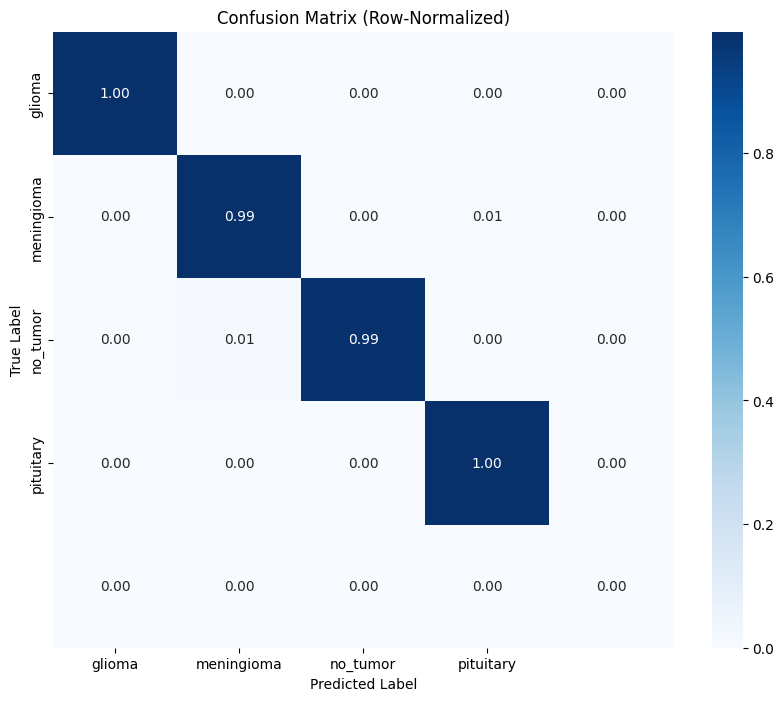

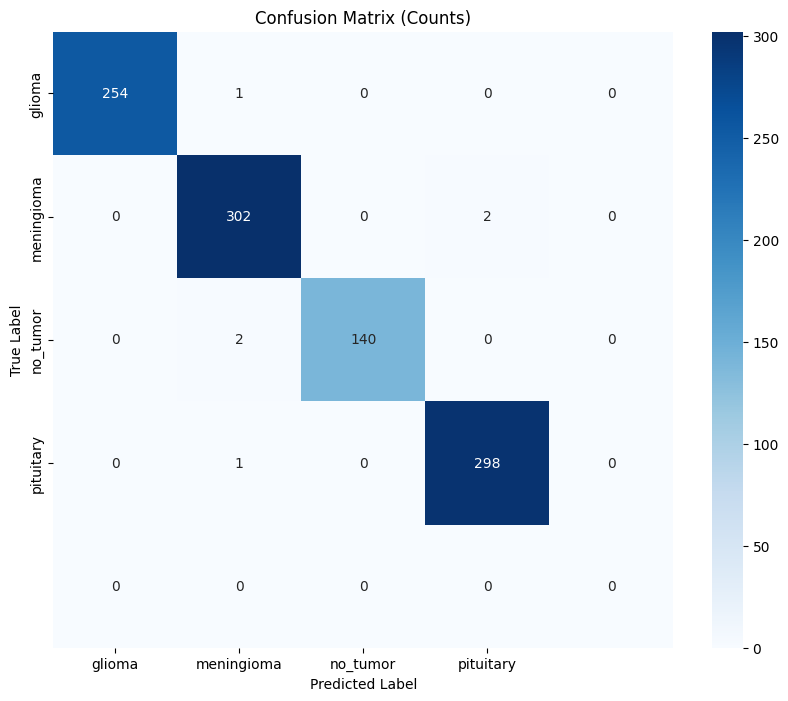

In [12]:
# After validation
cm = metrics.confusion_matrix.matrix 

# Get class names
class_names = list(model.names.values())

# ---- Row‑wise normalization (percent of true class) ----
cm_row_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Replace NaN (where row sum = 0) with 0
cm_row_norm = np.nan_to_num(cm_row_norm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_row_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Row‑Normalized)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ---- the raw counts ----
plt.figure(figsize=(10, 8))
sns.heatmap(cm.astype(int), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Counts)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

plots

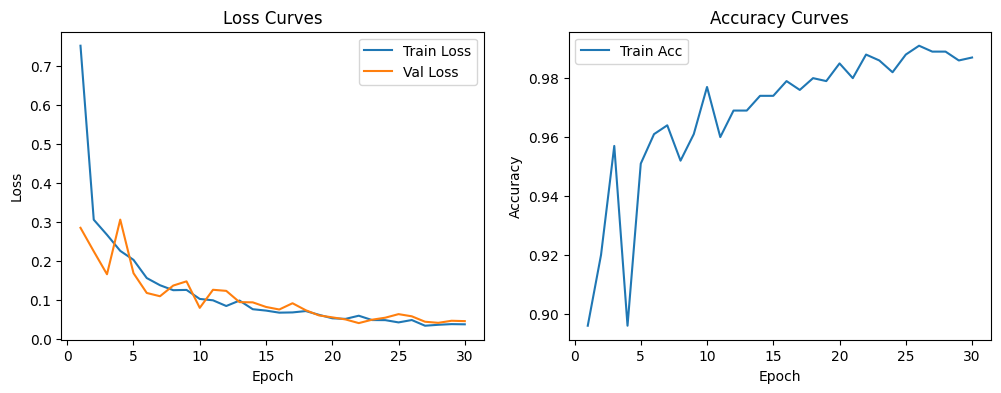

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('runs/classify/yolo_with_my_preproc2/results.csv')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(df['epoch'], df['train/loss'], label='Train Loss')
plt.plot(df['epoch'], df['val/loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(df['epoch'], df['metrics/accuracy_top1'], label='Train Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curves')
plt.show()


image 1/1 e:\Amr college\Grad project\Models\YOLO_classify\..\..\Dataset\Test_images\Gillioma(1).jpeg: 224x224 glioma 1.00, meningioma 0.00, pituitary 0.00, no_tumor 0.00, 7.1ms
Speed: 2.8ms preprocess, 7.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)


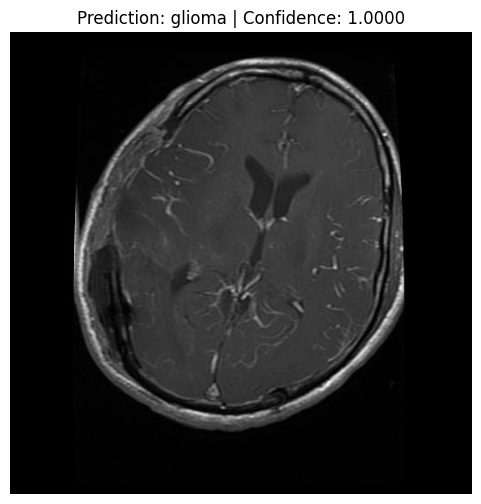

In [ ]:
def read_preprocess_image(img_path):
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Failed to load: {img_path}")

    img = cv2.resize(img, (224, 224))
    
    img = img.astype(np.float32)  # Convert to float32 for further processing
    
    # Apply Gaussian blur to reduce noise
    img = cv2.GaussianBlur(img, (3, 3), 0)
    
    return img

# 1. Construct the correct path to the trained model file
model_path = os.path.join('runs', 'classify', 'yolo_with_my_preproc2', 'weights', 'best.pt')
# Or use 'last.pt' if you want the final checkpoint instead of the best one

# 2. Load the model
best_model = YOLO(model_path)

# Predict on a test image
img_path = '../../Dataset/Test_images/Gillioma(1).jpeg'
results = best_model.predict(img_path)

#3. plotting

# Extract prediction result
result = results[0]

# Get predicted class index and confidence
predicted_class = result.probs.top1
confidence = result.probs.top1conf.item()

# Map index to class name
class_name = best_model.names[predicted_class]

# Read image again for plotting (grayscale)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title(f"Prediction: {class_name} | Confidence: {confidence:.4f}")
plt.axis("off")
plt.show()


Export into tflite

In [ ]:
# Export the trained model to TensorFlow Lite format
best_model.export(format='tflite')
best_model.export(format='tflite', int8=True)   # for integer quantization